## 사용할 데이터: FashionMNIST


In [6]:
# 라이브러리 호출
import torch
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim

In [7]:
# FashionMNIST 데이터셋 내려받기
trainset = torchvision.datasets.FashionMNIST(root='../chap08/data/', train=True,
                                        download=True,
                                        transform=transforms.ToTensor())

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.8MB/s]


In [ ]:
# trainloader 변수: 호출될 때 데이터셋을 메모리로 가져옴
batch_size = 4 # 데이터를 가져올 때 한 번에 네 개씩 쪼개서 가져옴
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

In [ ]:
# 데이터셋 분리
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
2


출력결과 torch.Size([4, 1, 28, 28]) 에서
- 4 : 한 번의 배치 크기로 4개의 데이터를 가져옴
- 1 : 채널을 의미, 1은 흑백 이미지
- 28x28 : (너비x높이) 픽셀 크기의 이미지

In [ ]:
# 이미지 데이터 출력을 위한 전처리
def imshow(img, title):
    plt.figure(figsize=(batch_size * 4, 4)) # 출력할 개별 이미지의 크기 지정
    plt.axis('off')
    plt.imshow(np.transpose(img, (1, 2, 0))) # 맷플롯립으로의 출력을 위해 데이터 형태 변경 시 사용하는 메서드
    plt.title(title)
    plt.show()

In [ ]:
# 이미지 출력을 위한 그래프 방식 정의
def show_batch_images(dataloader):
    images, labels = next(iter(dataloader))

    img = torchvision.utils.make_grid(images) # 좌표에 이미지 픽셀을 대응시킨 그리드 형태로 출력
    imshow(img, title=[str(x.item()) for x in labels]) # imshow 함수로 데이터의 형태가 hxwxc로 변경됨

    return images, labels

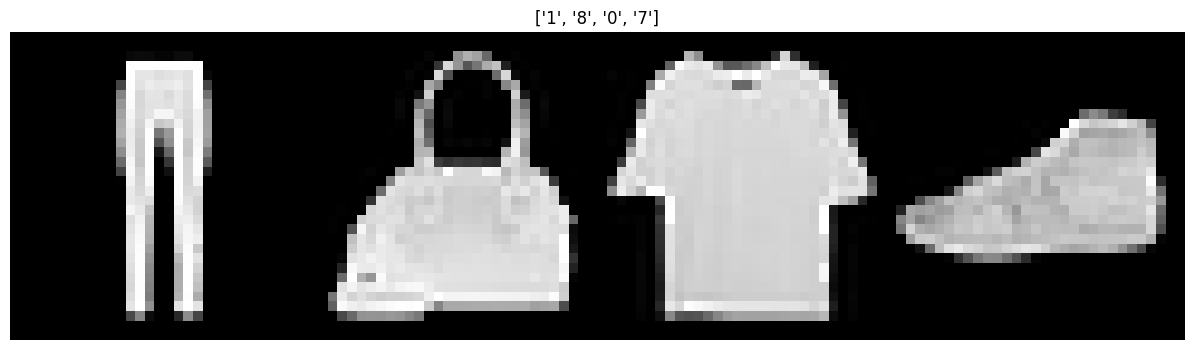

In [ ]:
# 이미지 출력
images, labels = show_batch_images(trainloader)

상위에 표시된 숫자는 클래스(레이블을 의미)
- 1은 바지, 8은 가장, 0은 티셔츠, 7은 운동화

In [ ]:
# 모델 네트워크 구축 : 배치정규화 적용X 모델
class NormalNet(nn.Module):
    def __init__(self):
        super(NormalNet, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(784, 48),  # 28 x 28 = 784
            nn.ReLU(),
            nn.Linear(48, 24),
            nn.ReLU(),
            nn.Linear(24, 10) # 클래스 10개
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [ ]:
# 배치 정규화가 포함된 네트워크
class BNNet(nn.Module):
    def __init__(self):
        super(BNNet, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(784, 48),
            nn.BatchNorm1d(48), # 배치 정규화 적용 부분
            nn.ReLU(),
            nn.Linear(48, 24),
            nn.BatchNorm1d(24),
            nn.ReLU(),
            nn.Linear(24, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [ ]:
# 배치정규화 적용x 모델 선언
model = NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [ ]:
# 배치정규화 적용o 모델 선언
model_bn = BNNet()
print(model_bn)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [ ]:
# 데이터로더로 데이터셋 메모리로 불러오기
batch_size = 512 # 학습용도로 배치 크기 512
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

In [ ]:
# 모델에서 사용할 옵티마이저, 손실 함수 지정
loss_fn = nn.CrossEntropyLoss()
opt = optim.SGD(model.parameters(), lr=0.01)
opt_bn = optim.SGD(model_bn.parameters(), lr=0.01)

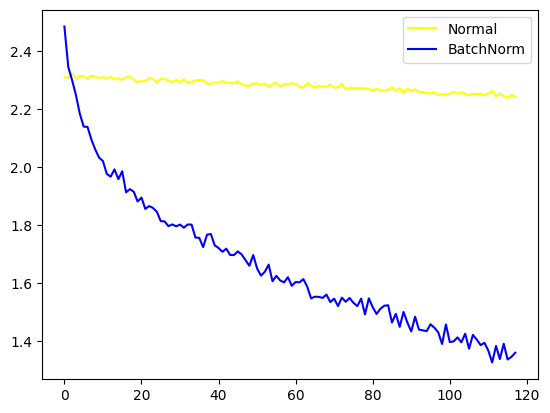

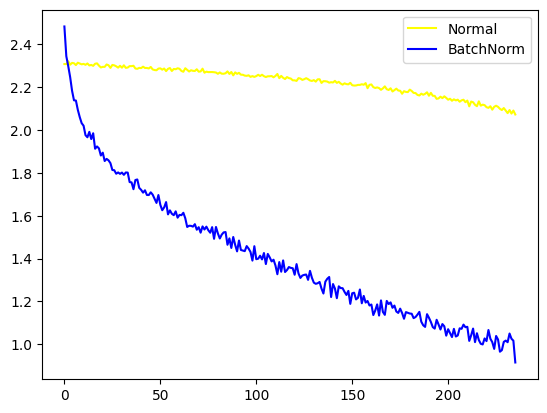

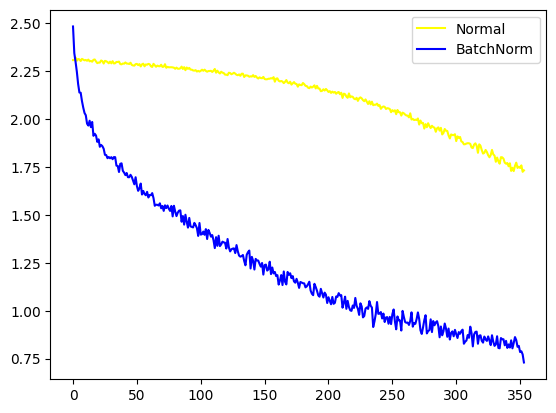

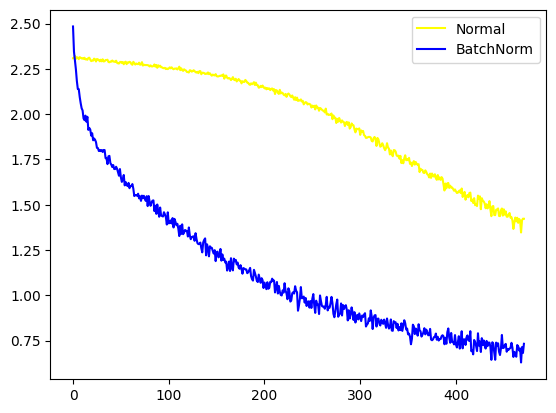

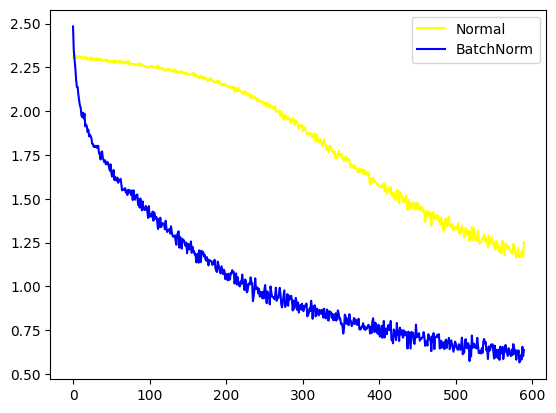

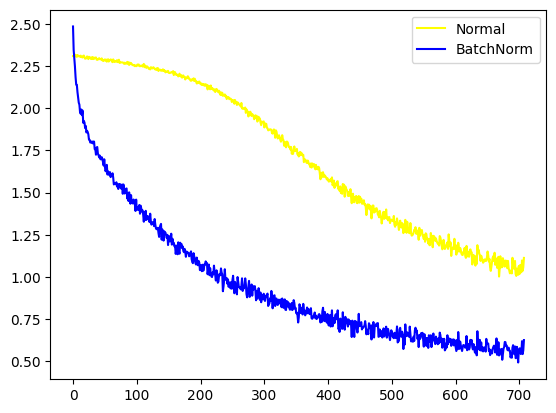

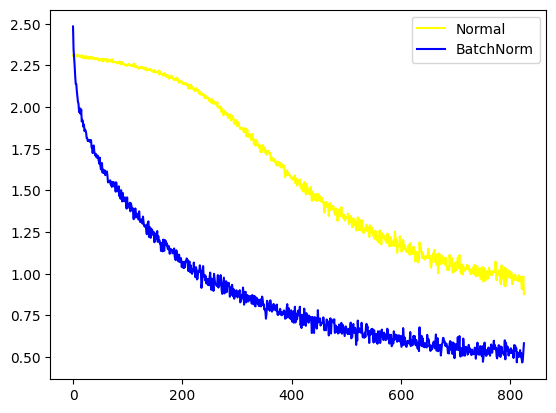

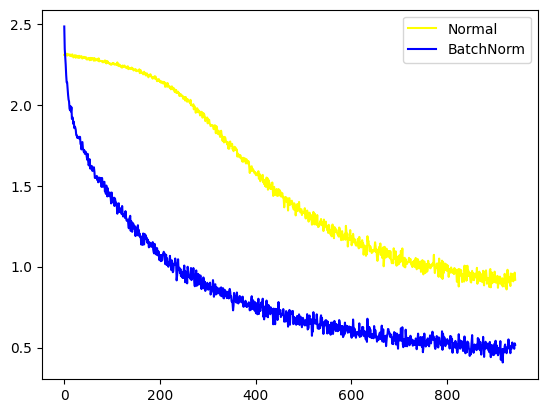

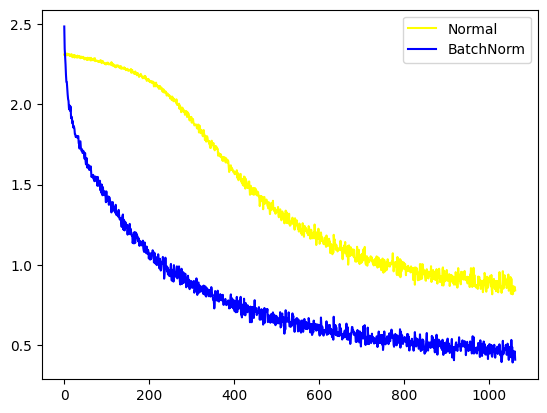

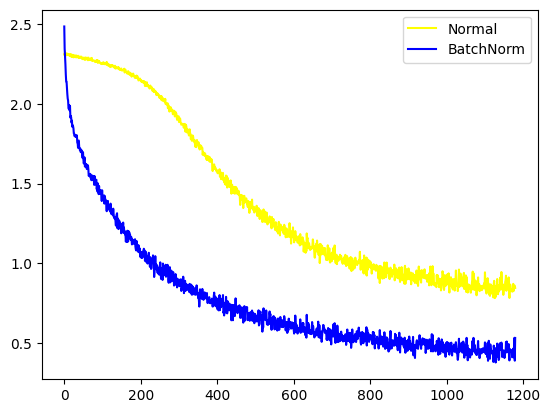

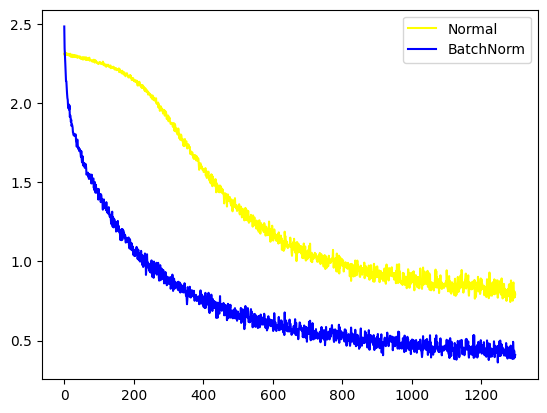

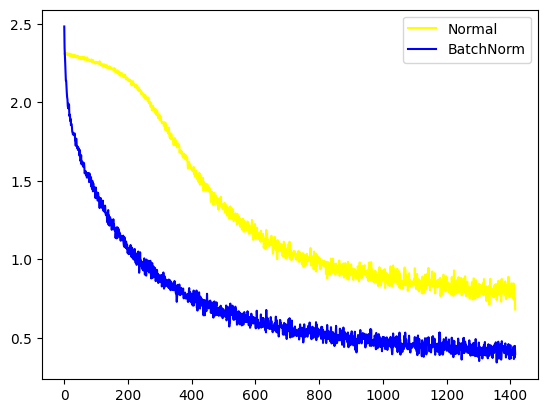

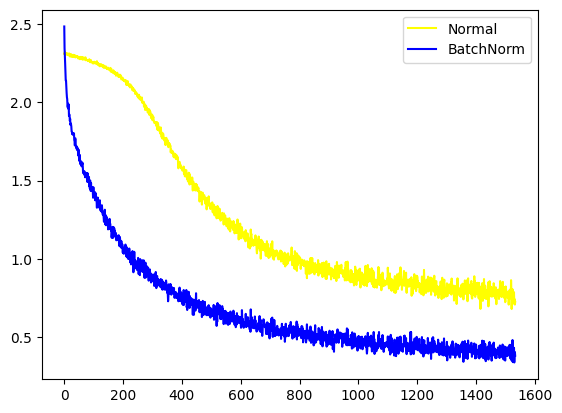

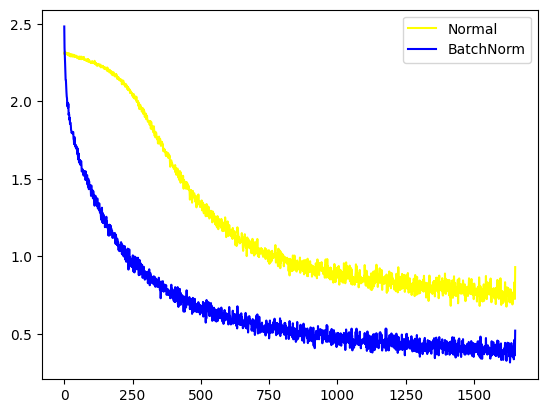

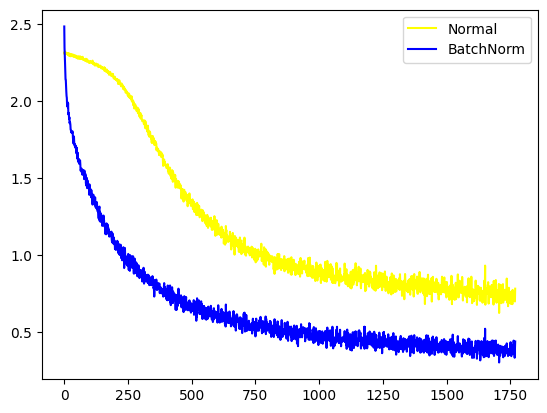

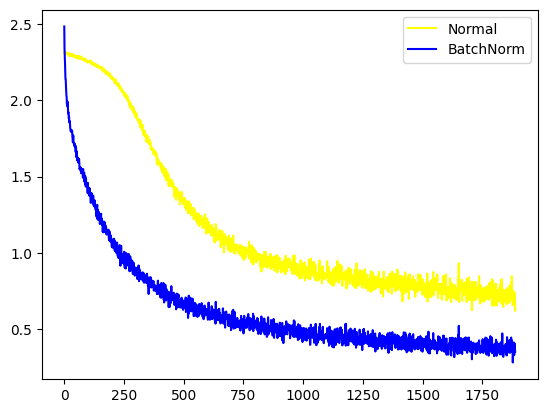

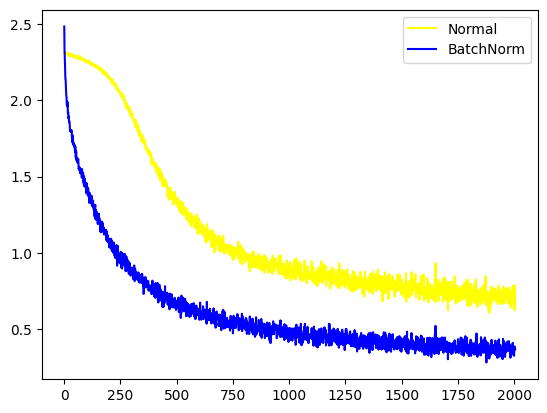

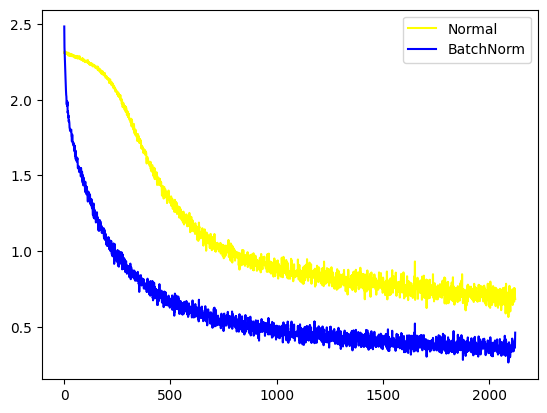

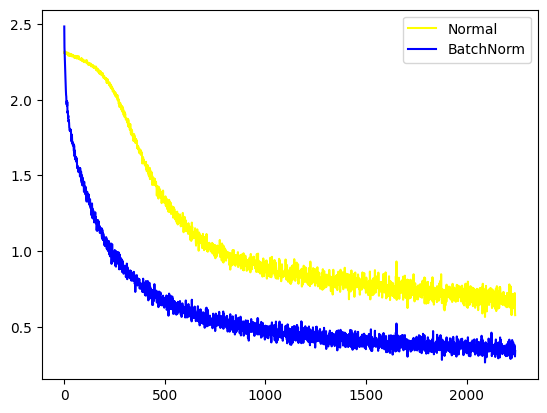

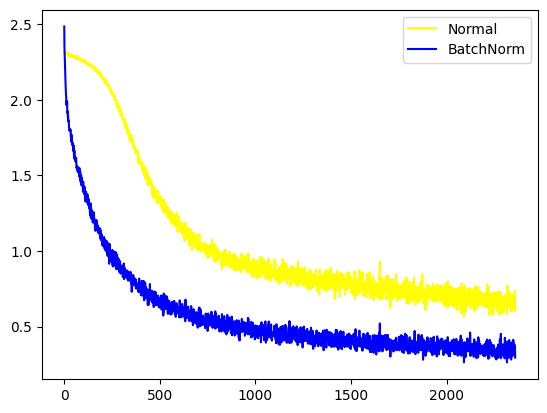

In [ ]:
# 모델 학습
loss_arr = []
loss_bn_arr = []
max_epochs = 20

for epoch in range(max_epochs):
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        opt.zero_grad() # 배치정규화 적용x 모델 학습
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        opt.step()

        opt_bn.zero_grad() # 배치정규화 적용o 모델 학습
        outputs_bn = model_bn(inputs)
        loss_bn = loss_fn(outputs_bn, labels)
        loss_bn.backward()
        opt_bn.step()

        loss_arr.append(loss.item())
        loss_bn_arr.append(loss_bn.item())

    plt.plot(loss_arr, 'yellow', label='Normal')
    plt.plot(loss_bn_arr, 'blue', label='BatchNorm')
    plt.legend()
    plt.show()

In [ ]:
# 데이터셋 분포 출력을 위한 전처리
N = 50
noise = 0.3

x_train = torch.unsqueeze(torch.linspace(-1, 1, N), 1) # 훈련데이터셋 스케일링
# linspace(-1, 1, N): -1~1 범위에서 N개의 균등한 값을 갖는 텐서 생성
# torch.unsqueeze : 차원 증가
y_train = x_train + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1)) # 훈련데이터셋 정규분포화
# torch.normal: 정규분포로부터 무작위 표본 추출
x_test = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_test = x_test + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

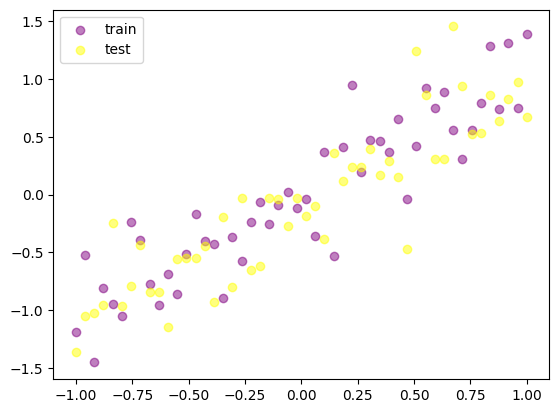

In [ ]:
# 데이터 분포 그래프로 출력
plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple', alpha=0.5, label='train')
# plt.scatter(x,y, c, alpha, label)
## x: x축 데이터, y:y축 데이터, c:마커색상, alpha:마커투명도, label:legend 역할
plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow', alpha=0.5, label='test')
plt.legend()
plt.show()

In [ ]:
# 드롭아웃을 위한 모델 생성
N_h = 100
model = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
) # 드롭아웃 적용x

model_dropout = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.Dropout(0.2), # 드롭아웃
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
) # 드롭아웃 적용O

In [ ]:
# 옵티마이저와 손실함수 지정
opt = torch.optim.Adam(model.parameters(), lr=0.01)
opt_dropout = torch.optim.Adam(model_dropout.parameters(), lr=0.01)
loss_fn = torch.nn.MSELoss()

/tmp/ipython-input-662928583.py:30: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.title('Epoch %d, Loss = %0.4f, Loss with dropout = %0.4f' % (epoch, test_loss, test_loss_dropout))


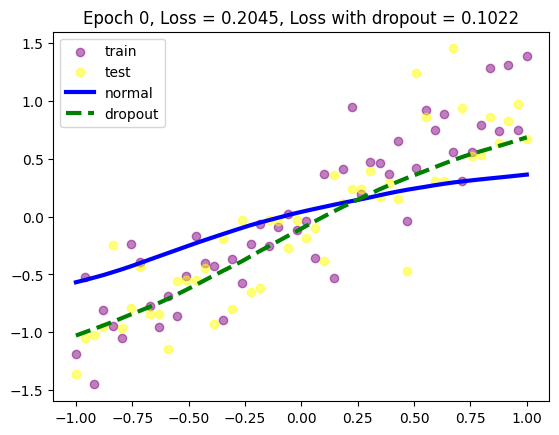

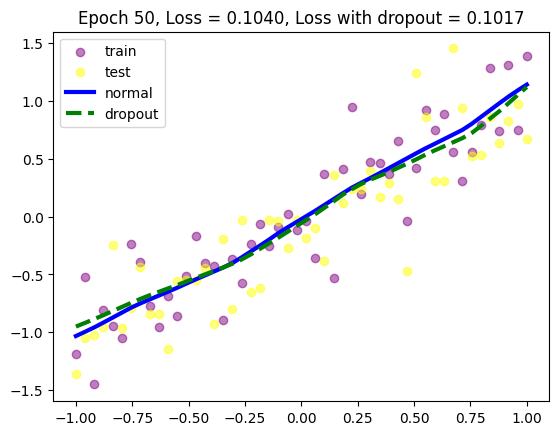

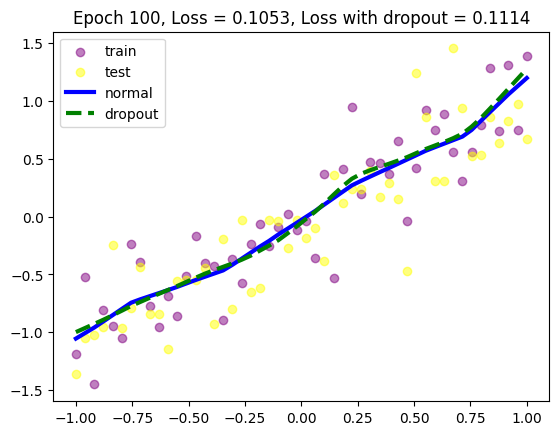

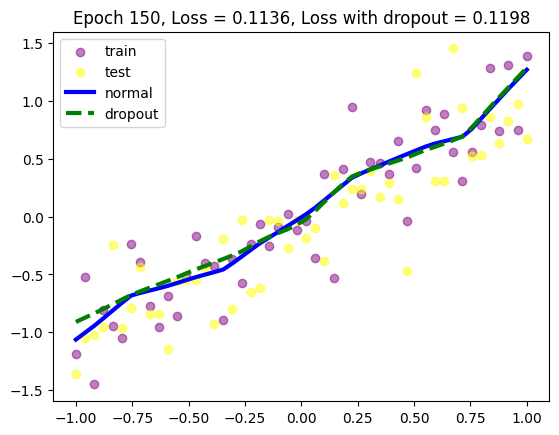

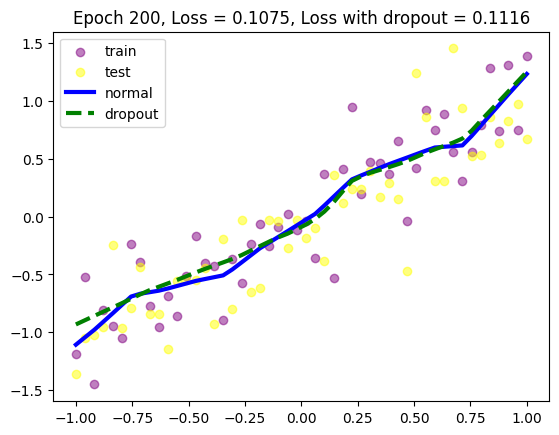

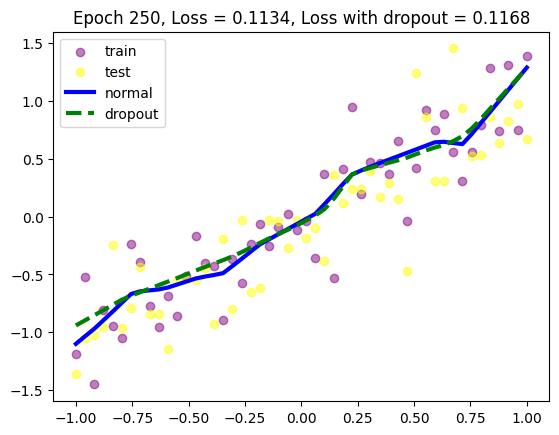

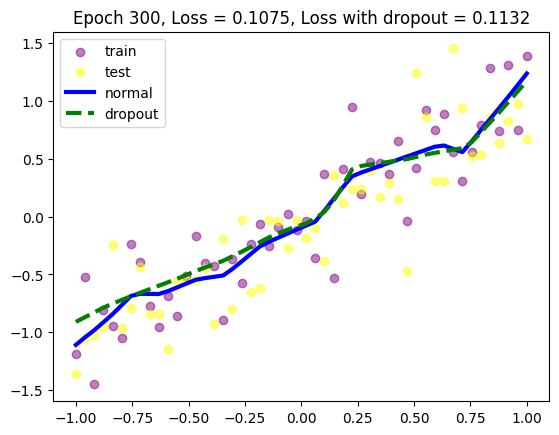

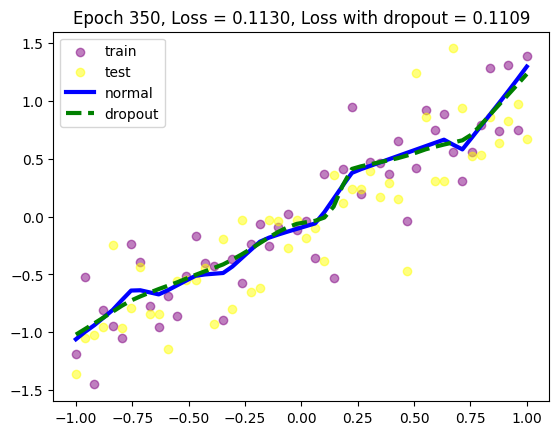

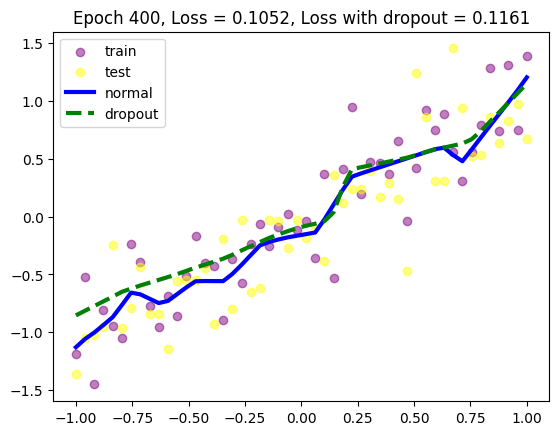

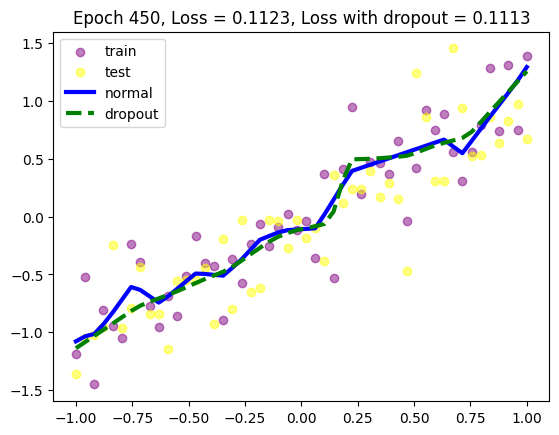

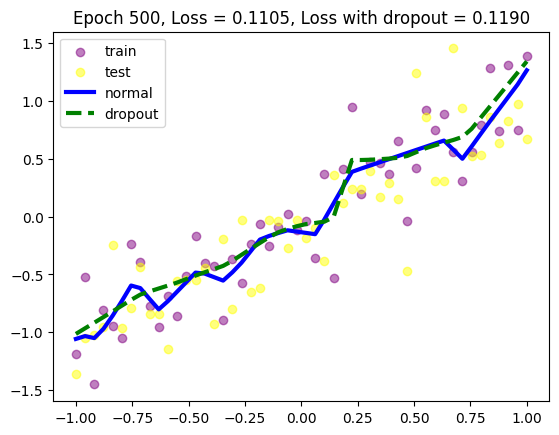

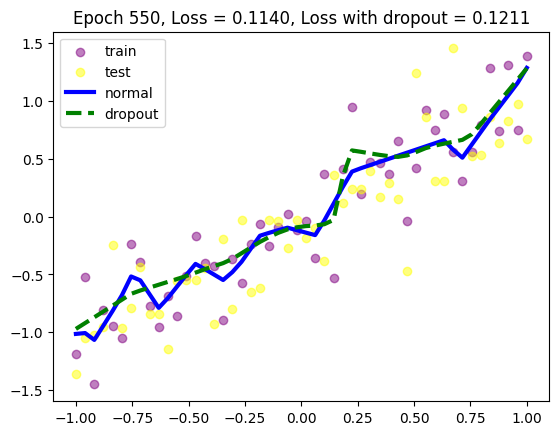

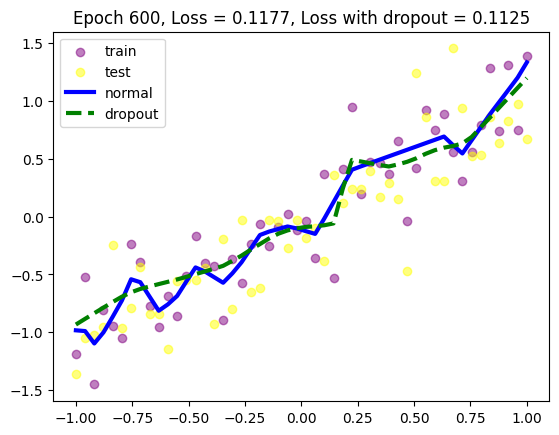

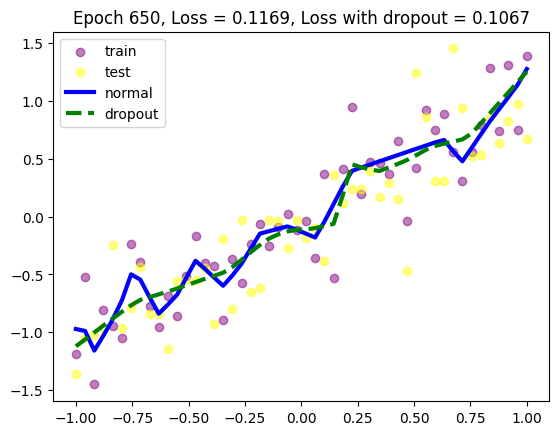

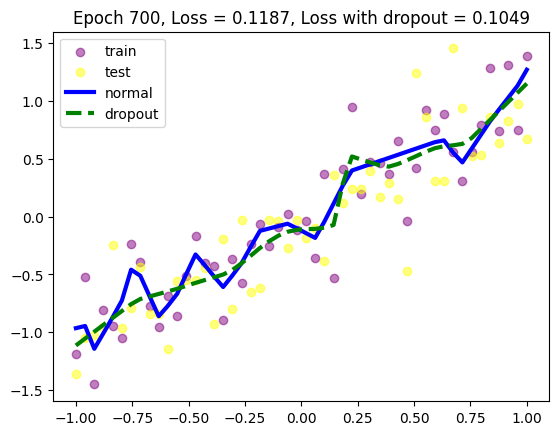

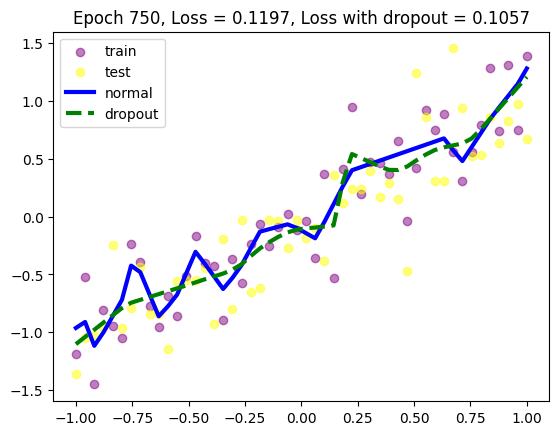

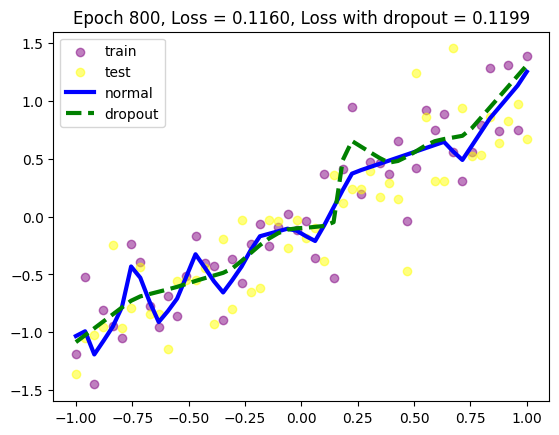

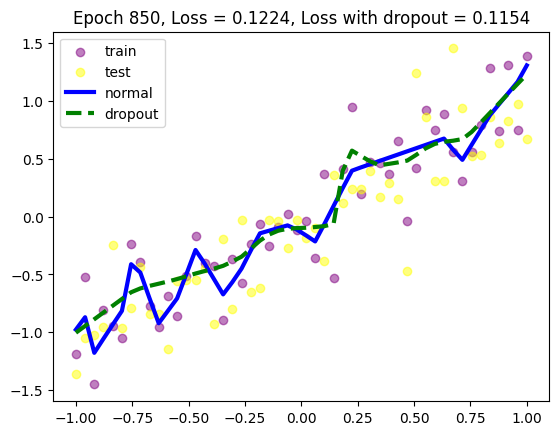

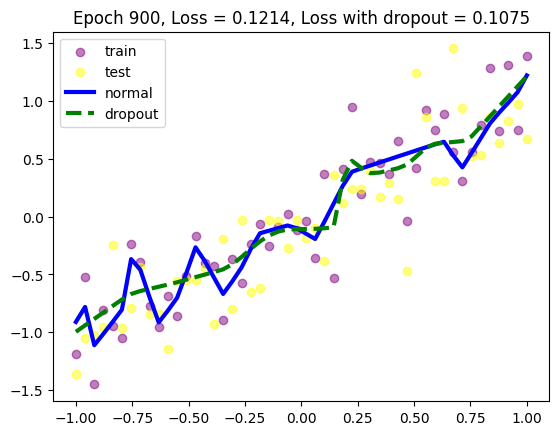

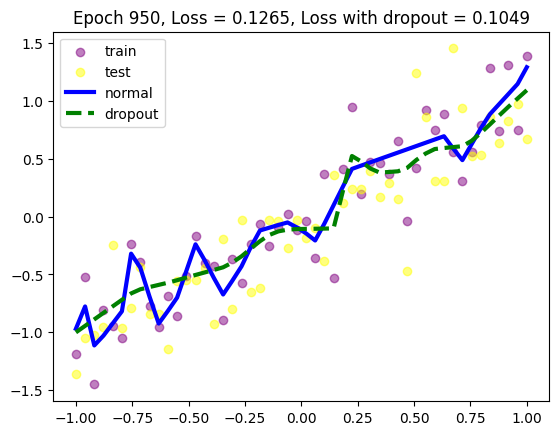

In [ ]:
# 모델 학습
max_epochs = 1000
for epoch in range(max_epochs):
    pred = model(x_train)
    loss = loss_fn(pred, y_train)
    opt.zero_grad()
    loss.backward()
    opt.step()

    pred_dropout = model_dropout(x_train) # 드롭아웃 적용 모델 학습
    loss_dropout = loss_fn(pred_dropout, y_train)
    opt_dropout.zero_grad()
    loss_dropout.backward()
    opt_dropout.step()

    if epoch % 50 == 0:
        model.eval()
        model_dropout.eval()

        test_pred = model(x_test)
        test_loss = loss_fn(test_pred, y_test)

        test_pred_dropout = model_dropout(x_test)
        test_loss_dropout = loss_fn(test_pred_dropout, y_test)

        plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple', alpha=0.5, label='train')
        plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow', alpha=0.5, label='test')
        plt.plot(x_test.data.numpy(), test_pred.data.numpy(), 'b-', lw=3, label='normal')
        plt.plot(x_test.data.numpy(), test_pred_dropout.data.numpy(), 'g--', lw=3,  label='dropout')

        plt.title('Epoch %d, Loss = %0.4f, Loss with dropout = %0.4f' % (epoch, test_loss, test_loss_dropout))
        plt.legend()
        model.train()
        model_dropout.train()
        plt.pause(0.05)

# 조기 종료를 이용한 성능 최적화 실습

In [1]:
# 라이브러리 호출
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms, datasets

import matplotlib
import matplotlib.pyplot as plt
import time
import argparse
from tqdm import tqdm
matplotlib.style.use('ggplot') # 출력 그래프에서 격자로 숫자 범위가 눈에 잘 띄도록 하는 스타일

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # GPU 사용을 위한 코드

In [8]:
# 데이터셋 전처리
# 캐글에서 제공하는 핫도그 데이터셋을 활용한다.
train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

In [10]:
# 데이터셋 가져오기
train_dataset = datasets.ImageFolder(
    root='/content/drive/MyDrive/archive/train',
    transform=train_transform
)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True,
)
val_dataset = datasets.ImageFolder(
    root=r'/content/drive/MyDrive/archive/test',
    transform=val_transform
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size=32, shuffle=False, # 한 번에 32개의 이미지를 불러옴
)

In [11]:
# 모델 생성
# 사전 학습된 ResNet50 사용
def resnet50(pretrained=True):
    model = models.resnet50(progress=True, pretrained=pretrained)
    if requires_grad == False: # 파라미터를 고정하여 역전파 과정 중에 기울기 계산X
        for param in model.parameters():
            param.requires_grad = False
    elif requires_grad == True: # 파라미터 값이 backward() 중에 기울기 계싼에 반영
        for param in model.parameters():
            param.requires_grad = True
    model.fc = nn.Linear(2048, 2) # 마지막 분류를 위한 계층은 학습 진행
    return model

In [12]:
# 학습률 감소: 학습 과정에서 학습률을 조금씩 낮추어 준다.
## 주어진 patience 횟수만큼 검증 데이터셋에 대한 오차 감소가 없으면 주어진 factor만큼 학습률을 감소시킴
class LRScheduler():
    def __init__(
        self, optimizer, patience=5, min_lr=1e-6, factor=0.5
    ):
        self.optimizer = optimizer
        self.patience = patience
        self.min_lr = min_lr
        self.factor = factor
        self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( # 검증데이터셋에 대한 오차변동x -> 학습률 factor배 감소
                self.optimizer, # 파라미터 갱신 부분
                mode='min', # mode: 학습률 조정 기준이 되는 값
                patience=self.patience, # patience: 학습률 업데이터 전 기다릴 에포크의 수
                factor=self.factor, # factor: 학습률 감소 정도 파라미터
                min_lr=self.min_lr, # min_lr: 학습률 하한선
                verbose=True # verbose: 조기 종료의 시작과 끝
            ) # 학습 과정에서 모델 성능에 대한 개선이 없을 경우 학습률 값을 조절하여 모델 개선 유도
    def __call__(self, val_loss):
        self.lr_scheduler.step(val_loss) # 학습률 업데이트

In [14]:
# 조기 종료 클래스
class EarlyStopping():
    def __init__(self, patience=5, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience # patience: 개선이 없는 에포크를 기다려줄 횟수
        self.verbose = verbose
        self.counter = 0
        self.best_score = None # 검증데이터셋에 대한 오차 최적화 값
        self.early_stop = False # 조기종료 초기값은 false
        self.delta = delta # delta: 오차 개선 판단을 위한 최소 변화량, 변화량이 delta보다 작으면 개선X로 판단
        self.path = path

    def __call__(self, val_loss, model): # 에포크만큼 학습을 반복하며 best_loss 갱신, 진전 없을 시 조기 종료 후 모델 저장
        score = -val_loss

        if self.best_score is None: # best_score에 값이 존재x -> 실행
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else: # 그 외 모든 경우에 실행
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [18]:
# 인수 값 지정
parser = argparse.ArgumentParser()
parser.add_argument('--lr-scheduler', dest='lr_scheduler', action='store_true')
# 첫 번째 파라미터: 옵션 문자열의 이름, 명령 실행 시 사용
# dest: action을 store_true로 지정하면 입력 값을 dest 파라미터에 의해 생성된 변수에 저장
parser.add_argument('--early-stopping', dest='early_stopping', action='store_true')
args = vars(parser.parse_args([])) # 입력받은 인수값이 실제로 args 변수에 저장

In [19]:
# 라이브러리 설치
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.9 MB/s eta 0:00:00


In [20]:
# 사전 훈련된 모델의 파라미터 확인
print(f"Computation device: {device}\n") # 사용하는 hw 종류 검사
model = models.resnet50(pretrained=True).to(device) # 사전 훈련된 ResNet50 사용
total_params = sum(p.numel() for p in model.parameters()) # 총 파라미터 수
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad) # 학습 가능한 파라미터 수
print(f"{total_trainable_params:,} training parameters.")

Computation device: cuda



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 81.7MB/s]


25,557,032 total parameters.
25,557,032 training parameters.


- 실행 결과에서 cuda를 사용하고 있음을 확인할 수 있다.

In [21]:
# 옵티마이저, 손실함수 지정
lr = 0.001
epochs = 100
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

In [22]:
# 오차, 정확도 및 모델 이름에 대한 문자 지정
loss_plot_name = 'loss'
acc_plot_name = 'accuracy'
model_name = 'model'

In [23]:
if args['lr_scheduler']:
    print('INFO: Initializing learning rate scheduler')
    lr_scheduler = LRScheduler(optimizer)
    loss_plot_name = 'lrs_loss' # 학습률 감소 적용 오차
    acc_plot_name = 'lrs_accuracy' # 학습률 감소 적용 정확도
    model_name = 'lrs_model' # 학습률 감소 모델명
if args['early_stopping']:
    print('INFO: Initializing early stopping')
    early_stopping = EarlyStopping()
    loss_plot_name = 'es_loss' # 조기 종료 적용 오차
    acc_plot_name = 'es_accuracy' # 조기 종료 적용 정확도
    model_name = 'es_model' # 조기 종료 적용 모델명

In [24]:
# 모델 학습 함수
def training(model, train_dataloader, train_dataset, optimizer, criterion):
    print('Training')
    model.train()
    train_running_loss = 0.0
    train_running_correct = 0
    counter = 0
    total = 0
    prog_bar = tqdm(enumerate(train_dataloader), total=int(len(train_dataset)/train_dataloader.batch_size))
    for i, data in prog_bar:
        counter += 1
        data, target = data[0].to(device), data[1].to(device)
        total += target.size(0)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        train_running_loss += loss.item()
        _, preds = torch.max(outputs.data, 1)
        train_running_correct += (preds == target).sum().item()
        loss.backward()
        optimizer.step()

    train_loss = train_running_loss / counter
    train_accuracy = 100. * train_running_correct / total
    return train_loss, train_accuracy

In [25]:
# 모델 검증 함수
def validate(model, test_dataloader, val_dataset, criterion):
    print('Validating')
    model.eval()
    val_running_loss = 0.0
    val_running_correct = 0
    counter = 0
    total = 0
    prog_bar = tqdm(enumerate(test_dataloader), total=int(len(val_dataset)/test_dataloader.batch_size))
    with torch.no_grad():
        for i, data in prog_bar:
            counter += 1
            data, target = data[0].to(device), data[1].to(device)
            total += target.size(0)
            outputs = model(data)
            loss = criterion(outputs, target)

            val_running_loss += loss.item()
            _, preds = torch.max(outputs.data, 1)
            val_running_correct += (preds == target).sum().item()

        val_loss = val_running_loss / counter
        val_accuracy = 100. * val_running_correct / total
        return val_loss, val_accuracy

In [26]:
train_loss, train_accuracy = [], []
val_loss, val_accuracy = [], []
start = time.time()
for epoch in range(epochs):
    print(f"Epoch {epoch+1} of {epochs}")
    train_epoch_loss, train_epoch_accuracy = training(
        model, train_dataloader, train_dataset, optimizer, criterion
    )
    val_epoch_loss, val_epoch_accuracy = validate(
        model, val_dataloader, val_dataset, criterion
    )
    train_loss.append(train_epoch_loss)
    train_accuracy.append(train_epoch_accuracy)
    val_loss.append(val_epoch_loss)
    val_accuracy.append(val_epoch_accuracy)
    if args['lr_scheduler']:
        lr_scheduler(val_epoch_loss)
    if args['early_stopping']:
        early_stopping(val_epoch_loss, model)
        if early_stopping.early_stop:
            break
    print(f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}")
    print(f'Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}')
end = time.time()
print(f"Training time: {(end-start)/60:.3f} minutes")

Epoch 1 of 100
Training


16it [02:37,  9.85s/it]


Validating


16it [02:48, 10.54s/it]


Train Loss: 2.2526, Train Acc: 57.63
Val Loss: 26.2199, Val Acc: 39.20
Epoch 2 of 100
Training


...

Train Loss: 0.0306, Train Acc: 99.40
Val Loss: 0.9178, Val Acc: 77.20
Epoch 100 of 100
Training


16it [00:05,  2.98it/s]


Validating


16it [00:04,  3.46it/s]

Train Loss: 0.0329, Train Acc: 98.80
Val Loss: 1.0309, Val Acc: 74.80
Training time: 24.150 minutes


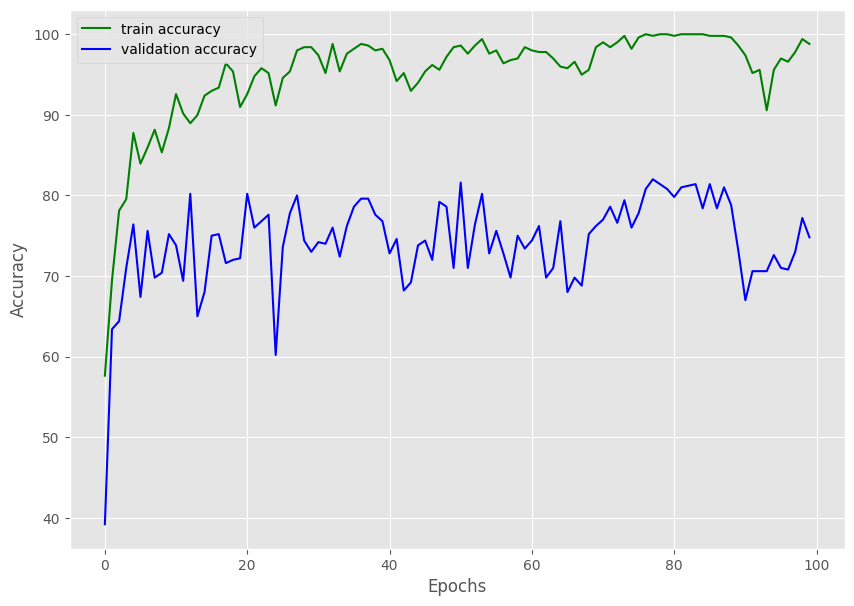

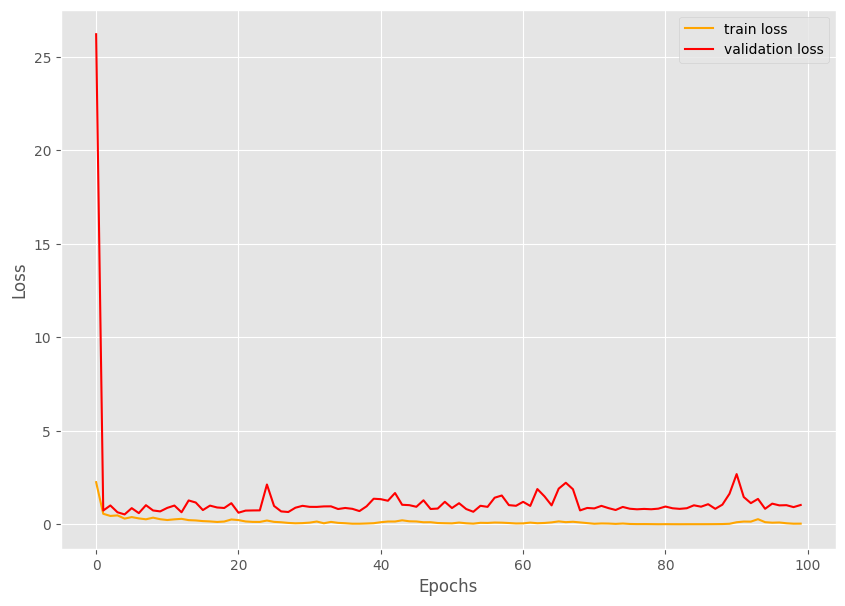

Saving model...
TRAINING COMPLETE


In [27]:
# 모델 학습 결과 출력
plt.figure(figsize=(10, 7))
plt.plot(train_accuracy, color='green', label='train accuracy')
plt.plot(val_accuracy, color='blue', label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f"/content/drive/MyDrive/archive/{acc_plot_name}.png")
plt.show()

plt.figure(figsize=(10, 7))
plt.plot(train_loss, color='orange', label='train loss')
plt.plot(val_loss, color='red', label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f"/content/drive/MyDrive/archive/{loss_plot_name}.png")
plt.show()

print('Saving model...')
torch.save(model.state_dict(), f"/content/drive/MyDrive/archive/{model_name}.pth")
print('TRAINING COMPLETE')